In [1]:
import tensorflow as tf
import numpy as np
import pickle
import pandas as pd
import random
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical    
import os
os.chdir('/home/harry_munday/robolearn/autonomous_robots/AI/Tensor_flow/CNN_from_scratch/traffic-signs-data/')


2025-11-23 09:32:15.396149: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763890335.413483    2181 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763890335.418791    2181 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763890335.435609    2181 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763890335.435638    2181 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763890335.435640    2181 computation_placer.cc:177] computation placer alr

In [2]:
training_file = 'train.p'
validation_file = 'valid.p'
testing_file = 'test.p'

with open(training_file, mode='rb') as f:
    train = pickle.load(f)
with open(validation_file, mode='rb') as f:
    valid = pickle.load(f)
with open(testing_file, mode='rb') as f:
    test = pickle.load(f)

X_train, y_train = train['features'], train['labels']
X_valid, y_valid = valid['features'], valid['labels']
X_test, y_test = test['features'], test['labels']

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

# Normalize images (keeping shape 32x32x3) 0-255 normalizing vlaues to 0-1 
X_train = (X_train )/255
X_valid = (X_valid )/255
X_test = (X_test)/255

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=43) # suppose 1st class is "speed limit 50" that will be 1000000000000.till43(0)
# similarlly suppose second class is "no right turn" so that will be 01000000000...43(0)
y_valid_cat = to_categorical(y_valid, num_classes=43)
y_test_cat = to_categorical(y_test, num_classes=43)   # [0.3,0.0022,0.8,0.333, 0.001 ...43th]=given by softmax    
# 0000100000..43(0)=given label in one-hot encoded form       crossentropy = -log(0.001)  =N

# Build CNN Model
model = models.Sequential()
# 1st Convolutional Layer #input 32,32,3  output 32-5/1 + 1 =28 ==> 28,28,6
model.add(layers.Conv2D(filters=6, kernel_size=(5,5), strides=(1,1), padding="valid", activation='relu', input_shape=(32,32,3))) 
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))    #input is (28,28,6)   output(14,14,6)   

# 2nd Convolutional Layer   #input is (14,14,6)  output is(10,10,16) 14-5/1 + 1=  10
model.add(layers.Conv2D(filters=16, kernel_size=(5,5), strides=(1,1), padding='valid', activation='relu')) 
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))   #input is 10,10,16   output is 5,5, 16

# Flatten
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(120, activation='relu'))
model.add(layers.Dense(80, activation='relu'))
model.add(layers.Dense(43, activation='softmax'))  # Output layer (43 classes)       
 
# Compile Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training Parameters
batch_size = 128
epochs = 3

# Training with Evaluation after Each Epoch
history = model.fit(X_train, y_train_cat,
                    validation_data=(X_valid, y_valid_cat),
                    epochs=epochs,
                    batch_size=batch_size)

# Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test, y_test_cat) 
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# Load Sign Names CSV
sign_names = pd.read_csv('./signnames.csv')



Train: (34799, 32, 32, 3), Valid: (4410, 32, 32, 3), Test: (12630, 32, 32, 3)


/home/harry_munday/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1763890341.187327    2181 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-11-23 09:32:22.486931: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 427610112 exceeds 10% of free system memory.
2025-11-23 09:32:23.269945: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 427610112 exceeds 10% of free system memory.


Epoch 1/3


I0000 00:00:1763890344.421634    2254 service.cc:152] XLA service 0x7bacac004df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763890344.421680    2254 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-11-23 09:32:24.457988: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763890344.659121    2254 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-11-23 09:32:25.582504: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_329', 372 bytes spill stores, 372 bytes spill loads

2025-11-23 09:32:25.927465: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusi

 26/272 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0470 - loss: 3.6942

...

272/272 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.5084 - loss: 1.9051 - val_accuracy: 0.7240 - val_loss: 1.0107
Epoch 2/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8476 - loss: 0.5632 - val_accuracy: 0.8061 - val_loss: 0.6937
Epoch 3/3
272/272 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9163 - loss: 0.3217 - val_accuracy: 0.8308 - val_loss: 0.6482


2025-11-23 09:32:53.973531: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_113', 76 bytes spill stores, 76 bytes spill loads



383/395 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8319 - loss: 0.8351

2025-11-23 09:32:56.514980: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_113', 4 bytes spill stores, 4 bytes spill loads

2025-11-23 09:32:57.589532: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_113', 56 bytes spill stores, 56 bytes spill loads



395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8324 - loss: 0.8382
Final Test Accuracy: 83.24%


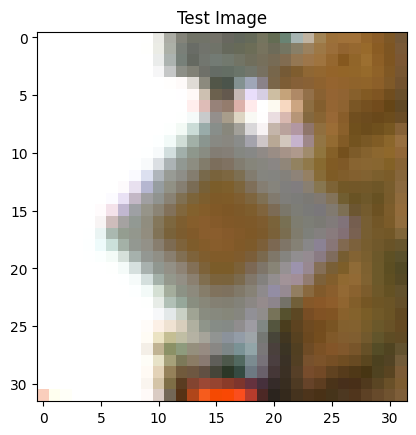

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 508ms/step
[[7.94307938e-21 3.20223720e-14 8.60435312e-14 4.10833645e-10
  1.01082775e-22 5.15860575e-13 1.52867979e-11 6.55402677e-11
  2.85584748e-18 5.68992533e-08 3.49864443e-10 4.37890267e-04
  9.99557912e-01 9.43429446e-10 5.39166178e-21 1.28643476e-20
  1.04176422e-06 6.10667797e-24 2.31995479e-18 1.16755744e-10
  1.96659269e-11 3.29324523e-12 3.72826237e-28 3.74203890e-10
  2.00657091e-14 5.65166457e-13 1.42231360e-13 1.77074525e-14
  1.33157414e-08 7.02944596e-15 5.81384718e-08 2.67811086e-11
  2.89263863e-10 1.31849115e-18 1.18029678e-19 1.93425964e-13
  6.97964790e-20 6.69468448e-23 2.93852543e-15 4.70556397e-28
  1.66318280e-13 2.37959114e-07 2.90528737e-06]]
Predicted Label: 12 -> Priority road
True Label: 12 -> Priority road


In [3]:
# Predict Random Test Image
random_idx = random.randint(0, len(X_test)-1)
sample_image = X_test[random_idx]
true_label = y_test[random_idx]

plt.imshow(sample_image)
plt.title("Test Image")
plt.show()

# Expand dims for prediction
sample_input = np.expand_dims(sample_image, axis=0)
pred_probs = model.predict(sample_input)
# print(pred_probs)
pred_label = np.argmax(pred_probs)

# Get Class Names
pred_name = sign_names.loc[pred_label]['SignName']
true_name = sign_names.loc[true_label]['SignName']

print(f"Predicted Label: {pred_label} -> {pred_name}")
print(f"True Label: {true_label} -> {true_name}")